## EXORL and OGBench benchmarks testing

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time

# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.fourrooms_discrete import FourRoomsGridWorld, FourRoomsGoalWrapper
from utils import TrajectoryReplayBufferDiscrete, evaluate_policy, set_seed
from visualisations import plot_policy_rollouts, plot_q_diagnostics
from loss_functions import repulsion_loss_to_memory
from benchmarks import make_env, load_dataset_into_buffer
from benchmarks.visualise import collect_episode_frames, save_gif


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


## EXORL test

In [2]:
env = make_env(
    benchmark="exorl",
    task="walker_walk",
    seed=0,
    render_mode="rgb_array",
    render_height=240,
    render_width=320,
    camera_id=0,
)

rollout = collect_episode_frames(env, max_steps=200)
print(rollout["num_steps"], rollout["total_reward"])

save_gif(rollout["frames"], "outputs/walker_walk.gif", fps=30)
env.close()

200 6.739683665251445


## OGBench Test

<class 'numpy.ndarray'> (200, 200, 3)


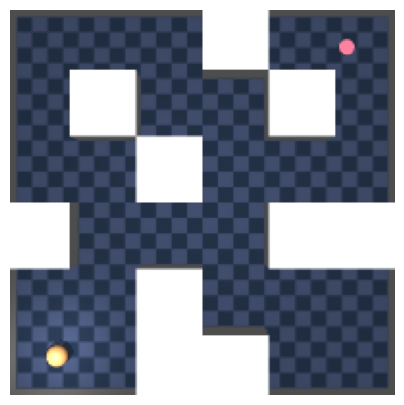

In [4]:
env = make_env("ogbench", "pointmaze-medium-navigate-v0")
obs, info = env.reset(options={"task_id": 1})

# Check if rendering works
frame = env.render()
print(type(frame), None if frame is None else frame.shape)

if frame is not None:
    plt.figure(figsize=(5, 5))
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

env.close()